# Practical 1 — Visual Wildlife Datasets

Before building any model, you need to understand the data. Wildlife
imagery comes from two main platforms — **camera traps** (ground-level)
and **drones** (aerial) — and each platform uses different annotation
formats to label what is in the images.

This practical walks through **four annotation types**, from simplest to
most detailed, showing real examples from public datasets at each level:

1. **Image classification** — one species label per photo
2. **Bounding boxes** — a rectangle around each animal
3. **Point annotations** — a single (x, y) coordinate per animal
4. **Segmentation masks** — pixel-level outlines (preview for Practical 7)

Each type trades off **annotation effort** against **spatial detail**.
By the end you will know which format each tool uses (MegaDetector → boxes,
HerdNet → points, SAM → masks) and when each is the right choice.

In [3]:
import sys
from pathlib import Path

# Resolve the shared data/ directory and the download_data module
DATA_BASE = Path.cwd().parent / "data"
SCRIPTS_DATA = Path.cwd().parents[1] / "scripts" / "data"

for p in [str(DATA_BASE), str(SCRIPTS_DATA)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"DATA_BASE: {DATA_BASE}")
print(f"SCRIPTS_DATA: {SCRIPTS_DATA}")

DATA_BASE: /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data
SCRIPTS_DATA: /Users/christian/work/hnee/usde-innovations-applications-forest-it/scripts/data


---

## 1. Image Classification

The simplest annotation type: **one label per image**. The entire photo
is tagged with a species name — no information about where the animal is
in the frame.

This is the format used by camera trap management platforms (Wildlife
Insights, Agouti, Trapper) and by species classifiers downstream of
MegaDetector.

**Snapshot Serengeti** — 7.1 million camera trap images from Tanzania,
40+ mammalian species, stored as COCO JSON with three top-level lists
(`images`, `annotations`, `categories`) linked by ID fields.

In [4]:
from download_data import download_serengeti
download_serengeti(n_images=50, output_dir=DATA_BASE)

/Users/christian/opt/anaconda3/envs/usde-innovations-applications-forest-it/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Snapshot Serengeti (n=50) ===
  411414 images in Season 1 metadata
  Sampled 50 images (72577 with animals available)


Serengeti images:  62%|██████▏   | 31/50 [00:00<00:00, 54.67it/s]

Serengeti images: 100%|██████████| 50/50 [00:01<00:00, 44.06it/s]

  Done. Images in /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/camera_trap/serengeti_subset


PosixPath('/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/camera_trap/serengeti_subset')

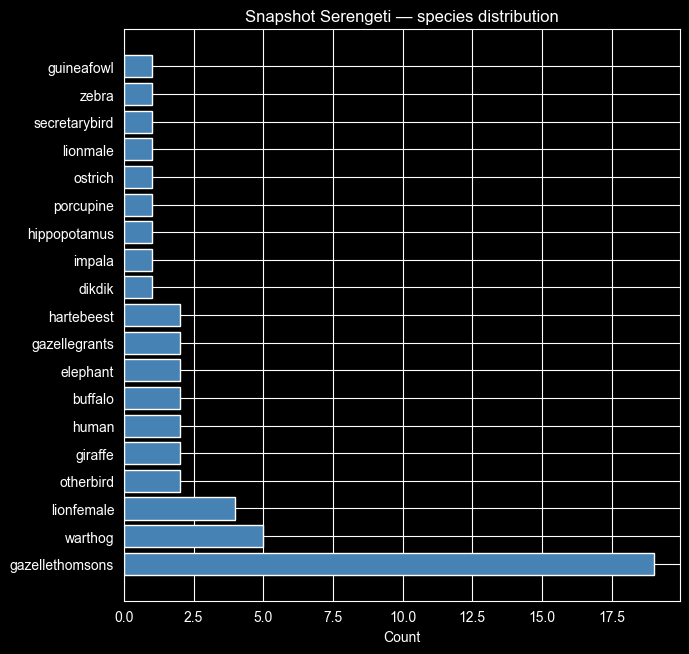

In [5]:
from download_data import show_class_distribution
show_class_distribution("serengeti", output_dir=DATA_BASE)

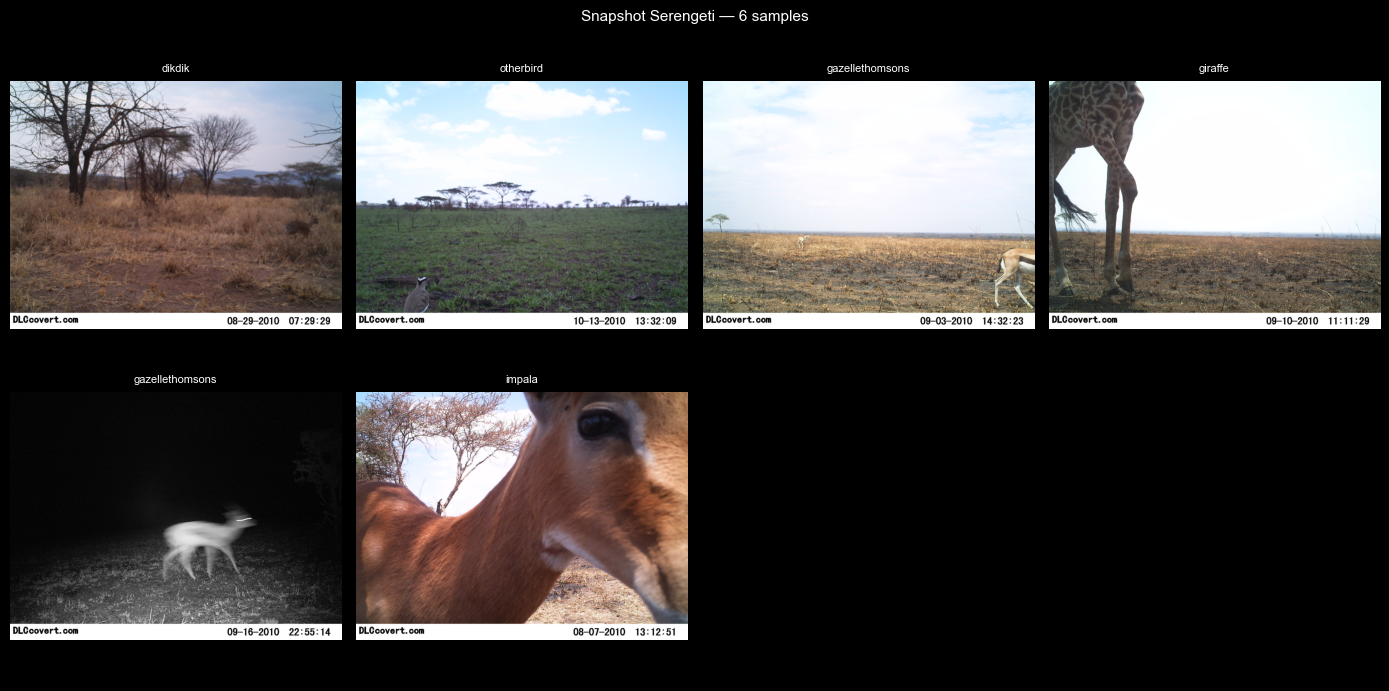

In [6]:
from download_data import show_samples
show_samples("serengeti", n=6, output_dir=DATA_BASE)

---

## 2. Bounding Boxes

A bounding box adds **spatial information**: a rectangle around each animal
tells you not just *what* is there, but *where* it is. This is the format
used by most object detectors: **MegaDetector**, **YOLOv8**, **Faster R-CNN**.

Three common bounding box formats exist — you will convert between them
in Practical 3:

| Format | Coordinates | Used by |
|--------|-------------|---------|
| **COCO** | `[x, y, w, h]` — top-left + size, pixels | COCO JSON, MegaDetector |
| **YOLO** | `[cx, cy, w, h]` — centre + size, normalised 0–1 | Ultralytics, training |
| **Pascal VOC** | `[x_min, y_min, x_max, y_max]` — corners, pixels | VOC XML |

We show bounding boxes from two perspectives:
- **Camera trap** (Serengeti) — ground-level, COCO format `[x, y, w, h]`
- **Aerial** (Eikelboom 2019) — nadir view, YOLO format `[cx, cy, w, h]`

In [7]:
from download_data import show_bboxes
show_bboxes("serengeti", n=6, output_dir=DATA_BASE)

No bounding box annotations in Serengeti subset


In [8]:
from download_data import download_eikelboom
download_eikelboom(n_images=50, output_dir=DATA_BASE)


=== Eikelboom 2019 (n=50 per split) ===
  test: 50/112 images
  train: 50/393 images
  val: 50/56 images
  Downloaded 150 images total
  train: 0 images
  val: 0 images
  test: 0 images
  Saved to /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/eikelboom


PosixPath('/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/eikelboom')

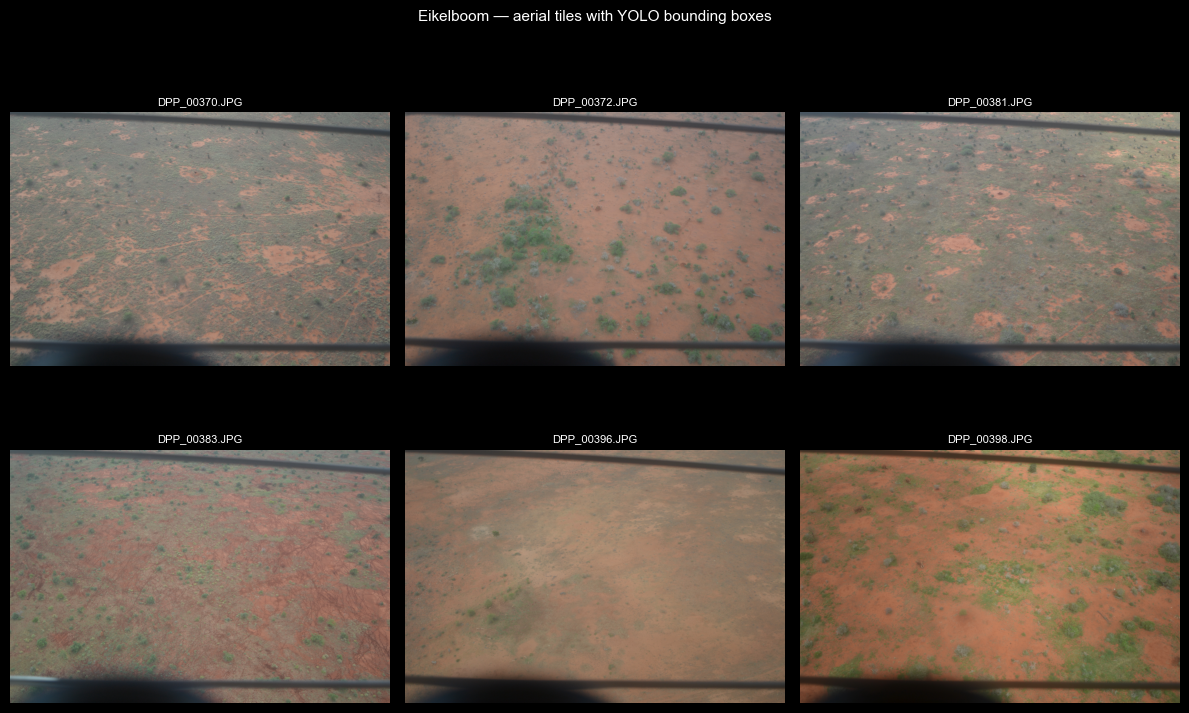

In [9]:
from download_data import show_bboxes
show_bboxes("eikelboom", n=6, output_dir=DATA_BASE)

In [10]:
from download_data import show_class_distribution
show_class_distribution("eikelboom", output_dir=DATA_BASE)

# TODO check this

No Eikelboom YOLO labels found


---

## 3. Point Annotations

A point annotation is the **lightest spatial label**: a single `(x, y)`
coordinate marking the centre of each animal. No box dimensions needed.

This dramatically reduces annotation effort — especially for **dense
colonies** where drawing tight boxes around overlapping animals is
impractical. It is the format used by **HerdNet** (Delplanque et al., 2023)
and the **Iguanas From Above** project throughout this course.

The HerdNet General Dataset stores annotations as a CSV:

| Column | Meaning |
|--------|---------|
| `images` | Tile filename |
| `x`, `y` | Pixel coordinate within the tile |
| `labels` | Species class |

**One row = one animal.** Tiles with no animals have no rows in the CSV.

In [11]:
from download_data import download_general_dataset
download_general_dataset(n_images=50, output_dir=DATA_BASE)


=== karisu/General_Dataset (n=50) ===
  Downloaded 50/1304 images
  Saved to /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/general_dataset


PosixPath('/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/general_dataset')

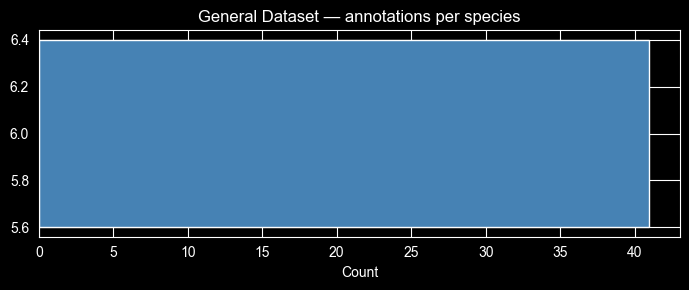

In [12]:
from download_data import show_class_distribution
show_class_distribution("general_dataset", output_dir=DATA_BASE)

Tiles: 7  |  Annotations: 41  |  Annotated tiles: 7  |  Median per tile: 4  |  Max: 12


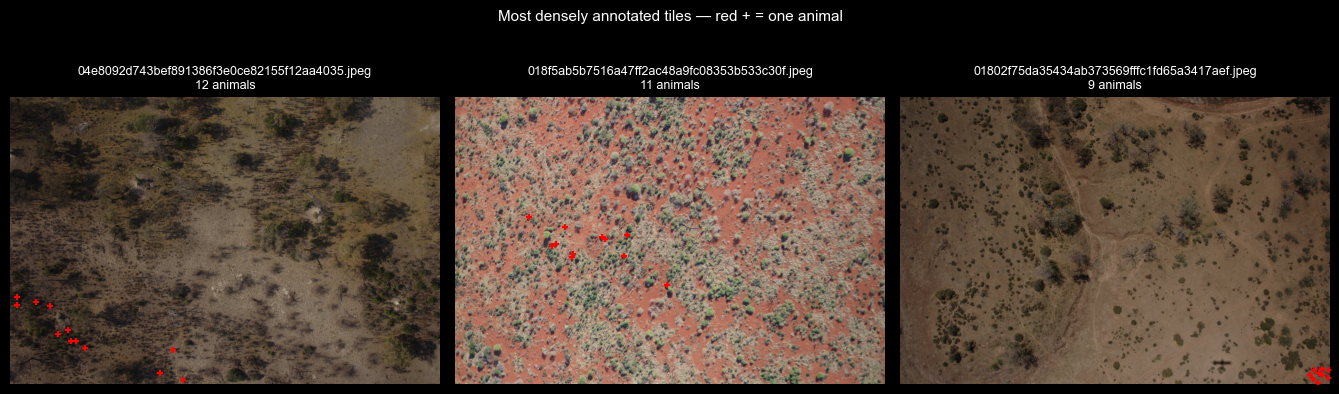

In [13]:
from download_data import show_annotated_tiles
show_annotated_tiles(n=3, output_dir=DATA_BASE)

---

## 4. Segmentation Masks (Preview)

The fourth and most detailed annotation type: **every pixel** is assigned
a class label. This is the most expensive to annotate but gives precise
outlines. You will work with this in **Practical 7** using Segment
Anything (SAM).

**When is segmentation useful in ecology?**
- Habitat mapping (land cover from satellite/drone imagery)
- Canopy delineation (individual tree crowns)
- Precise area estimation (coral coverage, burn scars)
- Instance segmentation when animals overlap heavily

---

## Summary — Annotation Types at a Glance

| Type | Spatial detail | Annotation effort | Example tools | Best for |
|------|---------------|-------------------|---------------|----------|
| **Image label** | None | Lowest | DeepFaune, SpeciesNet | Species ID after detection |
| **Bounding box** | Rectangle | Medium | MegaDetector, YOLOv8 | Counting, localisation |
| **Point** | Centre (x, y) | Low | HerdNet | Dense colonies, aerial |
| **Segmentation mask** | Pixel outline | Highest | SAM, U-Net | Habitat mapping, area |

More spatial detail is **not always better** — the right choice depends
on your ecological question and how much annotation time you can afford.

## Exercise

1. Compare a camera trap image with an aerial tile side by side.
   List three visual differences that would affect a detection model.
2. The Serengeti dataset uses bounding boxes; HerdNet uses points.
   Which annotation type would you choose for counting iguanas on a
   rocky beach? Why?
3. Look at the Eikelboom aerial images. How do the animals compare in
   size and visibility to the HerdNet tiles?
4. Point annotations are stored as pixel coordinates. What extra
   information would you need to convert them to GPS positions?

## Reflection

- Camera traps and drones produce very different data. How should this
  affect your choice of detection model?
- Empty tiles have no rows in the CSV. What does this mean for training
  a model that must also learn to say "nothing here"?
- The four annotation types form a hierarchy of increasing spatial detail.
  Is more detail always better, or is there a cost?